### Le modele de GVAR 

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dataclasses import dataclass

In [2]:
# ====== PARAMETRES DU MODELE ======
P = 0       # lags sur Z_i (domestique) : 1..P
P_star = 1  # lags sur Z_i* (étranger) : 0..P_star
L = 1       # lags sur X (macro) : 0..L

Z_FOLDER = "data/facteurs_systemiq/zt_am/zt_by_sector.csv"
MACRO_PATH = "data/macro_data/df_macro_stationary.csv"

OUTPUT_DIR = "data/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

W = "data/international_TES/W_USA.csv"


In [3]:
def load_Z_single_csv(path_csv: str) -> pd.DataFrame:
    """
    Charge un seul CSV contenant :
    sector, year_quarter, z_t
    et le transforme en matrice (date × secteur)
    """
    df = pd.read_csv(path_csv)

    df["year_quarter"] = pd.to_datetime(df["year_quarter"])

    # Pivot : lignes = date, colonnes = secteur
    Z = df.pivot(
        index="year_quarter",
        columns="sector",
        values="z_t"
    )

    Z = Z.sort_index()

    return Z


In [4]:
Z = load_Z_single_csv(Z_FOLDER)
Z.head(10)


sector,construction_immo,extraction_primaire,finance,industrie,info-com,public,services,services_pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439
2011-10-01,-1.656445,0.949014,-1.228758,-0.130107,-0.198410,0.643175,-0.834454,-2.045196
2012-01-01,1.672773,0.778933,-0.611153,-0.170126,-0.358526,0.083938,-0.810922,-1.409588
2012-04-01,-1.552605,-0.154775,0.600996,-0.041919,0.890062,-0.131946,0.371942,-0.410847
2012-07-01,-1.456050,-0.166745,0.900720,-0.216857,-0.450470,1.693689,0.398834,-0.410847


In [5]:
W_PATH = "data/international_TES/W_USA.csv"

W = pd.read_csv(W_PATH, index_col=0)
print(W.shape)
print(W.index[:5])
print(W.columns[:5])


(8, 8)
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='str')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='str')


In [6]:
W

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
Construction & immobilier,0.000000,0.091805,0.044308,0.042323,0.031832,0.351652,0.319931,0.118149
Finance,0.254573,0.000000,0.063530,0.029925,0.051587,0.268942,0.186638,0.144805
Industrie,0.228690,0.016663,0.000000,0.046987,0.111211,0.295704,0.225524,0.075221
Info-com,0.058195,0.099581,0.063383,0.000000,0.023975,0.297410,0.231898,0.225556
Primaires & énergie,0.124617,0.008341,0.605653,0.008270,0.000000,0.111432,0.114349,0.027337
Public & services non-marchands,0.143104,0.108869,0.115981,0.121381,0.104516,0.000000,0.262596,0.143553
Services,0.120531,0.034140,0.404891,0.051234,0.073470,0.217926,0.000000,0.097808
Services pro,0.123352,0.096037,0.132900,0.113900,0.047629,0.213727,0.272455,0.000000


In [7]:
print(Z.columns)
print(W.index)

Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='str', name='sector')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str')


In [8]:
W.iloc[:8, :8]

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
Construction & immobilier,0.000000,0.091805,0.044308,0.042323,0.031832,0.351652,0.319931,0.118149
Finance,0.254573,0.000000,0.063530,0.029925,0.051587,0.268942,0.186638,0.144805
Industrie,0.228690,0.016663,0.000000,0.046987,0.111211,0.295704,0.225524,0.075221
Info-com,0.058195,0.099581,0.063383,0.000000,0.023975,0.297410,0.231898,0.225556
Primaires & énergie,0.124617,0.008341,0.605653,0.008270,0.000000,0.111432,0.114349,0.027337
Public & services non-marchands,0.143104,0.108869,0.115981,0.121381,0.104516,0.000000,0.262596,0.143553
Services,0.120531,0.034140,0.404891,0.051234,0.073470,0.217926,0.000000,0.097808
Services pro,0.123352,0.096037,0.132900,0.113900,0.047629,0.213727,0.272455,0.000000


In [9]:
df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")
df_macro_stas.head()

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_18072\2834272364.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")


,date,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,EU_Central_bank_Intervention_rate_policy_interest_rate_diff,...,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
0,2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,NaN,...,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
1,2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,0.0,...,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2,2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,0.0,...,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
3,2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.0,...,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
4,2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,0.0,...,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [10]:
# Convertir la date en datetime
df_macro_stas["date"] = pd.to_datetime(df_macro_stas["date"])

# Mettre date en index
df_macro_stas = df_macro_stas.set_index("date")

df_macro_stas.head()

,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,EU_Central_bank_Intervention_rate_policy_interest_rate_diff,EU_Effective_exchange_rate_hp_gap,...,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,NaN,3.819471,...,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,0.0,-1.544360,...,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,0.0,-1.790578,...,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.0,0.232728,...,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,0.0,-0.114745,...,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [11]:
# Sélectionner colonnes contenant "US_"
us_cols = [col for col in df_macro_stas.columns if col.startswith("US_")]

df_macro_us = df_macro_stas[us_cols].copy()

df_macro_us.head()

,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Effective_exchange_rate_hp_gap,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_GDP_log,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
date,,,,,,,,,,,,,,,,,,
2010-01-01,0.484501,3.716667,76.674837,NaN,3.739092,NaN,0.066930,-0.724636,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
2010-04-01,0.967586,3.490000,78.845036,0.0,4.981713,1.242621,-0.088895,-0.032951,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2010-07-01,0.771085,2.786667,76.675000,0.0,3.671997,-1.309716,-0.016660,-0.259957,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
2010-10-01,0.525110,2.863333,87.033160,0.0,0.004494,-3.667503,0.050870,-0.644147,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
2011-01-01,-0.237205,3.460000,105.369424,0.0,-1.191876,-1.196370,0.074041,NaN,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [12]:
macro_vars = [
    "US_GDP_Growth_Rate",
    "US_Central_bank_Intervention_rate_policy_interest_rate_diff",
    "US_Long_term_interest_rate_hp_gap_diff",
    "US_Unemployment_rate_hp_gap_diff",
    "US_House_prices_residential_hp_gap_diff",
    "US_Effective_exchange_rate_hp_gap_diff",
    "US_Equity_prices_log_hp_gap",
    "US_Oil_price_log_hp_gap"
]

In [13]:
X = df_macro_stas[macro_vars].copy()
X.head()

,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
date,,,,,,,,
2010-01-01,0.484501,NaN,NaN,NaN,NaN,NaN,0.066930,-0.262272
2010-04-01,0.967586,0.0,-0.147168,0.014349,-0.673180,1.242621,-0.088895,-0.237845
2010-07-01,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092


In [14]:
# Au lieu de chercher la colonne "date", on manipule directement l'index
X.index = pd.to_datetime(X.index)
X = X.sort_index()
X.head()

,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
date,,,,,,,,
2010-01-01,0.484501,NaN,NaN,NaN,NaN,NaN,0.066930,-0.262272
2010-04-01,0.967586,0.0,-0.147168,0.014349,-0.673180,1.242621,-0.088895,-0.237845
2010-07-01,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092


In [15]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='str', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str')


In [16]:
rename_dict = {
    "construction_immo": "Construction & immobilier",
    "extraction_primaire": "Primaires & énergie",
    "finance": "Finance",
    "industrie": "Industrie",
    "info-com": "Info-com",
    "public": "Public & services non-marchands",
    "services": "Services",
    "services_pro": "Services pro"
}

Z = Z.rename(columns=rename_dict)


In [17]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['Construction & immobilier', 'Primaires & énergie', 'Finance',
       'Industrie', 'Info-com', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str')


In [18]:
# Secteurs : Z doit contenir tous les secteurs de W
missing = sorted(set(W.index) - set(Z.columns))
if missing:
    raise ValueError(f"Z ne contient pas tous les secteurs de W : {missing}")

# Garder uniquement les secteurs de W, dans le même ordre
Z = Z[W.index].copy()

# Alignement sur dates communes (et dropna)
df_base = pd.concat([Z, X], axis=1).dropna()

print("Z:", Z.shape, "| X:", X.shape, "| Base alignée:", df_base.shape)

Z: (51, 8) | X: (56, 8) | Base alignée: (51, 16)


C:\Users\HP\AppData\Local\Temp\ipykernel_18072\2212304547.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_base = pd.concat([Z, X], axis=1).dropna()


In [19]:
X_scenario=pd.read_csv("data/ngfs_data/ngfs_us.csv")

In [20]:
df_base.head()

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724


In [21]:
def compute_Z_star(Z: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    W2 = W.copy()
    Z_star = Z @ W2.T
    Z_star.columns = [f"{c}_star" for c in Z_star.columns]
    return Z_star

Z_star = compute_Z_star(Z, W)

# Dataset complet (Z, Z_star, X)
df_all = pd.concat([Z, Z_star, X], axis=1).dropna()
df_all.head()


C:\Users\HP\AppData\Local\Temp\ipykernel_18072\2245030967.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_all = pd.concat([Z, Z_star, X], axis=1).dropna()


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,Construction & immobilier_star,Finance_star,...,Services_star,Services pro_star,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,-1.564711,-1.865200,...,-0.934521,-1.582271,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,-0.913652,-1.024763,...,-0.392467,-0.791531,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,-1.051116,-0.290600,...,0.082451,-0.425792,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,-0.701743,0.040945,...,0.343530,-0.151725,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,-0.531434,0.162462,...,0.081461,-0.059817,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724


#################3 - stationnary + stepwise non par blocl ######

In [22]:
def build_full_design(df_all, sector, macro_cols, Pmax, Lmax):
    """
    Construit la matrice Xreg complète pour le secteur:
    const + Z*_lags (0..Pmax) + macros (k=1..K, l=0..Lmax)
    Retourne df_reg = [y | Xreg] dropna
    """
    y = df_all[sector].rename("y")
    parts = []

    # Z* lags
    zstar_col = f"{sector}_star"
    for p in range(Pmax + 1):
        parts.append(df_all[zstar_col].shift(p).rename(f"ZstarL{p}"))

    # Macros lags variable par variable
    for l in range(Lmax + 1):
        parts.append(df_all[macro_cols].shift(l).add_prefix(f"X_L{l}_"))

    Xreg = pd.concat(parts, axis=1)
    Xreg = sm.add_constant(Xreg, has_constant="add")

    df_reg = pd.concat([y, Xreg], axis=1).dropna()
    return df_reg

In [23]:
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd

def fit_bic(df_reg, kept_cols, alpha=10.0):
    """
    Estimation Ridge à la place de OLS.
    kept_cols doit inclure 'const'.
    Retourne params, pseudo-BIC
    """

    y = df_reg["y"].values
    X = df_reg[kept_cols].values

    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X, y)

    y_hat = model.predict(X)
    resid = y - y_hat

    n = len(y)
    k = X.shape[1]

    sigma2 = np.mean(resid**2)
    bic = n * np.log(sigma2) + k * np.log(n)

    params = pd.Series(model.coef_, index=kept_cols)

    return params, bic

In [24]:
def backward_stepwise_bic(df_reg, candidate_cols, always_keep=("const",), min_keep=3):
    """
    Backward elimination: on part avec tous les candidats,
    et on retire 1 variable à la fois si BIC diminue.
    """
    kept = list(dict.fromkeys(list(always_keep) + list(candidate_cols)))
    kept = [c for c in kept if c in df_reg.columns]

    res_full, best_bic = fit_bic(df_reg, kept)

    improved = True
    while improved:
        improved = False
        best_drop = None
        best_drop_bic = best_bic

        # candidats supprimables
        droppable = [c for c in kept if c not in always_keep]

        if len(droppable) <= min_keep:
            break

        for c in droppable:
            trial = [k for k in kept if k != c]
            try:
                _, bic = fit_bic(df_reg, trial)
            except Exception:
                continue

            if bic < best_drop_bic:
                best_drop_bic = bic
                best_drop = c

        if best_drop is not None:
            kept.remove(best_drop)
            best_bic = best_drop_bic
            improved = True

    final_res, final_bic = fit_bic(df_reg, kept)
    return kept, final_res, final_bic

In [25]:
def stepwise_macros_then_zstar(df_all, sector, macro_cols, Pmax=4, Lmax=4, iterate=False):
    df_reg = build_full_design(df_all, sector, macro_cols, Pmax=Pmax, Lmax=Lmax)

    # Colonnes Z* et macro dans le df_reg
    zstar_cols = [c for c in df_reg.columns if c.startswith("ZstarL")]
    macro_lag_cols = [c for c in df_reg.columns if c.startswith("X_L")]

    # --- Phase A : stepwise sur macros uniquement (Z* toujours gardé au départ)
    always_keep_A = ("const",) + tuple(zstar_cols)
    kept_A, res_A, bic_A = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=macro_lag_cols,
        always_keep=always_keep_A
    )

    # --- Phase B : stepwise sur Z* uniquement (macros sélectionnées fixées)
    selected_macro_cols = [c for c in kept_A if c.startswith("X_L")]
    always_keep_B = ("const",) + tuple(selected_macro_cols)
    kept_B, res_B, bic_B = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=zstar_cols,
        always_keep=always_keep_B
    )

    if not iterate:
        return kept_B, res_B, bic_B

    # Optionnel : itération A↔B (1 tour)
    # Re-phase A en gardant les Z* sélectionnés
    zstar_selected = [c for c in kept_B if c.startswith("ZstarL")]
    always_keep_A2 = ("const",) + tuple(zstar_selected)
    kept_A2, res_A2, bic_A2 = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=macro_lag_cols,
        always_keep=always_keep_A2
    )

    selected_macro_cols2 = [c for c in kept_A2 if c.startswith("X_L")]
    always_keep_B2 = ("const",) + tuple(selected_macro_cols2)
    kept_B2, res_B2, bic_B2 = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=zstar_cols,
        always_keep=always_keep_B2
    )

    return kept_B2, res_B2, bic_B2

In [26]:
sector = "Construction & immobilier"
macro_cols = list(X.columns)  # ou ta liste macro réduite

kept_cols, res, bic = stepwise_macros_then_zstar(
    df_all=df_all,
    sector=sector,
    macro_cols=macro_cols,
    Pmax=4,
    Lmax=4,      # retard max macro
    iterate=True # optionnel
)

print("BIC final:", bic)
print("Nb variables gardées:", len(kept_cols))
print("Variables gardées:", kept_cols)



BIC final: 12.45053917036703
Nb variables gardées: 7
Variables gardées: ['const', 'X_L0_US_House_prices_residential_hp_gap_diff', 'X_L1_US_House_prices_residential_hp_gap_diff', 'X_L4_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL4']


In [27]:
print(res.sort_values(key=abs, ascending=False))

X_L1_US_House_prices_residential_hp_gap_diff   -0.285159
X_L0_US_House_prices_residential_hp_gap_diff    0.221625
X_L4_US_House_prices_residential_hp_gap_diff    0.190870
ZstarL1                                         0.151890
ZstarL0                                        -0.099946
ZstarL4                                        -0.065212
const                                           0.037260
dtype: float64


In [28]:
def run_stepwise_all_sectors(df_all, sectors, macro_cols, Pmax=4, Lmax=4, iterate=False):
    # liste de colonnes possibles (max) pour construire un coef_df stable
    max_cols = ["const"] + [f"ZstarL{p}" for p in range(Pmax+1)]
    for l in range(Lmax+1):
        max_cols += [f"X_L{l}_{c}" for c in macro_cols]

    coef_df = pd.DataFrame(index=sectors, columns=max_cols, dtype=float)
    bic_series = pd.Series(index=sectors, dtype=float)

    kept_by_sector = {}

    for s in sectors:
        kept_cols, res, bic = stepwise_macros_then_zstar(
            df_all=df_all,
            sector=s,
            macro_cols=macro_cols,
            Pmax=Pmax,
            Lmax=Lmax,
            iterate=iterate
        )
        kept_by_sector[s] = kept_cols
        bic_series.loc[s] = bic

        # remplir coef_df (les non sélectionnés restent NaN)
        for name, val in res.params.items():
            if name in coef_df.columns:
                coef_df.loc[s, name] = val

    return coef_df, bic_series, kept_by_sector

In [29]:
def run_stepwise_all_sectors(df_all, sectors, macro_cols, Pmax=4, Lmax=4, iterate=False):

    max_cols = ["const"] + [f"ZstarL{p}" for p in range(Pmax+1)]
    for l in range(Lmax+1):
        max_cols += [f"X_L{l}_{c}" for c in macro_cols]

    coef_df = pd.DataFrame(index=sectors, columns=max_cols, dtype=float)
    bic_series = pd.Series(index=sectors, dtype=float)

    kept_by_sector = {}

    for s in sectors:

        kept_cols, params, bic = stepwise_macros_then_zstar(
            df_all=df_all,
            sector=s,
            macro_cols=macro_cols,
            Pmax=Pmax,
            Lmax=Lmax,
            iterate=iterate
        )

        kept_by_sector[s] = kept_cols
        bic_series.loc[s] = bic

        for name, val in params.items():
            if name in coef_df.columns:
                coef_df.loc[s, name] = val

    return coef_df, bic_series, kept_by_sector

In [30]:
sectors = list(Z.columns)
macro_cols = list(X.columns)

In [31]:
coef_df, bic_series, kept_by_sector = run_stepwise_all_sectors(
    df_all=df_all,
    sectors=sectors,
    macro_cols=macro_cols,
    Pmax=4,
    Lmax=4,
    iterate=False
)
print(kept_by_sector)

{'Construction & immobilier': ['const', 'X_L0_US_House_prices_residential_hp_gap_diff', 'X_L1_US_House_prices_residential_hp_gap_diff', 'X_L4_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL4'], 'Finance': ['const', 'X_L2_US_GDP_Growth_Rate', 'X_L2_US_Unemployment_rate_hp_gap_diff', 'X_L2_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL4'], 'Industrie': ['const', 'X_L0_US_Unemployment_rate_hp_gap_diff', 'X_L2_US_House_prices_residential_hp_gap_diff', 'X_L3_US_Oil_price_log_hp_gap', 'ZstarL0', 'ZstarL1', 'ZstarL4'], 'Info-com': ['const', 'X_L0_US_Unemployment_rate_hp_gap_diff', 'X_L0_US_House_prices_residential_hp_gap_diff', 'X_L1_US_GDP_Growth_Rate', 'X_L2_US_Unemployment_rate_hp_gap_diff', 'X_L3_US_Unemployment_rate_hp_gap_diff', 'X_L4_US_Unemployment_rate_hp_gap_diff', 'X_L4_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL3'], 'Primaires & énergie': ['const', 'X_L3_US_House_prices_residential_hp_gap_diff', 'X_L3_US_

In [32]:
coef_df

,const,ZstarL0,ZstarL1,ZstarL2,ZstarL3,ZstarL4,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,...,X_L3_US_Equity_prices_log_hp_gap,X_L3_US_Oil_price_log_hp_gap,X_L4_US_GDP_Growth_Rate,X_L4_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L4_US_Long_term_interest_rate_hp_gap_diff,X_L4_US_Unemployment_rate_hp_gap_diff,X_L4_US_House_prices_residential_hp_gap_diff,X_L4_US_Effective_exchange_rate_hp_gap_diff,X_L4_US_Equity_prices_log_hp_gap,X_L4_US_Oil_price_log_hp_gap
Construction & immobilier,0.037260,-0.099946,0.151890,NaN,NaN,-0.065212,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.190870,NaN,NaN,NaN
Finance,-0.182085,0.501628,0.261252,NaN,NaN,-0.082606,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industrie,0.006240,0.588063,0.377145,NaN,NaN,-0.204439,NaN,NaN,NaN,0.057067,...,NaN,-0.159759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Info-com,0.098358,0.275269,0.260817,NaN,0.17674,NaN,NaN,NaN,NaN,0.140576,...,NaN,NaN,NaN,NaN,NaN,0.107687,-0.146307,NaN,NaN,NaN
Primaires & énergie,0.010108,0.575424,NaN,0.205942,NaN,-0.180237,NaN,NaN,NaN,NaN,...,NaN,-0.350144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.433741
Public & services non-marchands,-0.095626,0.275435,0.206947,NaN,NaN,-0.142072,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.074543,NaN,NaN
Services,-0.070623,0.450427,0.244987,0.127090,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.179414,NaN,NaN,NaN,NaN,NaN
Services pro,-0.312263,0.597299,0.342469,NaN,NaN,-0.146267,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.096620,NaN,NaN


In [33]:
sectors = list(W.index)
macro_cols = list(X.columns)  # les macros que tu as retenues (K)

coef_df0 = coef_df.reindex(index=sectors).copy()
coef_df0 = coef_df0.fillna(0.0)  # <- règle : non retenu => 0

In [34]:
coef_df0

,const,ZstarL0,ZstarL1,ZstarL2,ZstarL3,ZstarL4,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,...,X_L3_US_Equity_prices_log_hp_gap,X_L3_US_Oil_price_log_hp_gap,X_L4_US_GDP_Growth_Rate,X_L4_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L4_US_Long_term_interest_rate_hp_gap_diff,X_L4_US_Unemployment_rate_hp_gap_diff,X_L4_US_House_prices_residential_hp_gap_diff,X_L4_US_Effective_exchange_rate_hp_gap_diff,X_L4_US_Equity_prices_log_hp_gap,X_L4_US_Oil_price_log_hp_gap
Construction & immobilier,0.037260,-0.099946,0.151890,0.000000,0.00000,-0.065212,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.190870,0.000000,0.0,0.000000
Finance,-0.182085,0.501628,0.261252,0.000000,0.00000,-0.082606,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
Industrie,0.006240,0.588063,0.377145,0.000000,0.00000,-0.204439,0.0,0.0,0.0,0.057067,...,0.0,-0.159759,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
Info-com,0.098358,0.275269,0.260817,0.000000,0.17674,0.000000,0.0,0.0,0.0,0.140576,...,0.0,0.000000,0.0,0.0,0.000000,0.107687,-0.146307,0.000000,0.0,0.000000
Primaires & énergie,0.010108,0.575424,0.000000,0.205942,0.00000,-0.180237,0.0,0.0,0.0,0.000000,...,0.0,-0.350144,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,-0.433741
Public & services non-marchands,-0.095626,0.275435,0.206947,0.000000,0.00000,-0.142072,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.074543,0.0,0.000000
Services,-0.070623,0.450427,0.244987,0.127090,0.00000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,-0.179414,0.000000,0.000000,0.000000,0.0,0.000000
Services pro,-0.312263,0.597299,0.342469,0.000000,0.00000,-0.146267,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.096620,0.0,0.000000


In [35]:
def build_B_matrices_from_coef(W: pd.DataFrame, coef_df0: pd.DataFrame, P_star: int) -> dict:
    N = W.shape[0]
    sectors = list(W.index)

    W2 = W.copy()

    B = {}
    for p in range(0, P_star + 1):
        col = f"ZstarL{p}"
        beta = coef_df0[col].reindex(sectors).values.reshape(N, 1) if col in coef_df0.columns else np.zeros((N,1))
        Bp = beta * W2.values  # diag(beta) @ W  (broadcasting)
        B[p] = pd.DataFrame(Bp, index=sectors, columns=sectors)

    return B

B = build_B_matrices_from_coef(W, coef_df0, P_star=4)
print("B0 shape:", B[0].shape)

B0 shape: (8, 8)


In [36]:
def build_Gamma_matrices_from_coef(coef_df0: pd.DataFrame, sectors: list, macro_cols: list, L: int) -> dict:
    Gamma = {}
    for l in range(0, L + 1):
        cols_l = [f"X_L{l}_{m}" for m in macro_cols]
        # si une colonne manque (par ex. jamais créée), on la crée à 0
        for c in cols_l:
            if c not in coef_df0.columns:
                coef_df0[c] = 0.0

        Gammal = coef_df0.loc[sectors, cols_l].values  # (N×K)
        Gamma[l] = pd.DataFrame(Gammal, index=sectors, columns=macro_cols)

    return Gamma

Gamma = build_Gamma_matrices_from_coef(coef_df0, sectors, macro_cols, L=4)
print("Gamma0 shape:", Gamma[0].shape)

Gamma0 shape: (8, 8)


In [37]:
Gamma

{0:                                  US_GDP_Growth_Rate  \
 Construction & immobilier                       0.0   
 Finance                                         0.0   
 Industrie                                       0.0   
 Info-com                                        0.0   
 Primaires & énergie                             0.0   
 Public & services non-marchands                 0.0   
 Services                                        0.0   
 Services pro                                    0.0   
 
                                  US_Central_bank_Intervention_rate_policy_interest_rate_diff  \
 Construction & immobilier                                                      0.0             
 Finance                                                                        0.0             
 Industrie                                                                      0.0             
 Info-com                                                                       0.0             
 Prima

In [38]:
def build_reduced_form(B: dict, Gamma: dict, coef_df0: pd.DataFrame, sectors: list, P_star: int, L: int):
    N = len(sectors)

    # c (constante empilée)
    if "const" in coef_df0.columns:
        c = coef_df0.loc[sectors, "const"].values.reshape(N, 1)
    else:
        c = np.zeros((N, 1))

    # G = I - B0
    I = np.eye(N)
    G = I - B[0].values

    # inverse
    Ginv = np.linalg.inv(G)

    # mu, Fp, tildeGamma
    mu = Ginv @ c

    F = {}
    for p in range(1, P_star + 1):
        F[p] = pd.DataFrame(Ginv @ B[p].values, index=sectors, columns=sectors)

    tildeGamma = {}
    for l in range(0, L + 1):
        tildeGamma[l] = pd.DataFrame(Ginv @ Gamma[l].values, index=sectors, columns=Gamma[l].columns)

    return (
        pd.DataFrame(G, index=sectors, columns=sectors),
        mu,
        F,
        tildeGamma
    )

G_mat, mu, F, tildeGamma = build_reduced_form(B, Gamma, coef_df0, sectors, P_star=P_star, L=L)

print("G shape:", G_mat.shape)
print("mu shape:", mu.shape)
print("F[1] shape:", F[1].shape if P_star >= 1 else None)
print("tildeGamma[0] shape:", tildeGamma[0].shape)

G shape: (8, 8)
mu shape: (8, 1)
F[1] shape: (8, 8)
tildeGamma[0] shape: (8, 8)


In [39]:
detG = np.linalg.det(G_mat.values)
condG = np.linalg.cond(G_mat.values)
print("det(G) =", detG)
print("cond(G) =", condG)

det(G) = 0.8929045379586323
cond(G) = 2.1566824946886616


In [40]:
import numpy as np
import pandas as pd

sectors = list(W.index)

# (1) récupérer c (constantes) sous forme vecteur (N,1)
c = coef_df0.loc[sectors, "const"].values.reshape(-1, 1) if "const" in coef_df0.columns else np.zeros((len(sectors), 1))

# (2) construire G = I - B0
N = len(sectors)
G = np.eye(N) - B[0].values

# (3) inverser
Ginv = np.linalg.inv(G)

# (4) mu
mu = Ginv @ c   # (N,1)

# (5) F_p
P_star = max(B.keys())  # si B contient p=0..P_star
F = {}
for p in range(1, P_star + 1):
    F[p] = pd.DataFrame(Ginv @ B[p].values, index=sectors, columns=sectors)

# (6) tildeGamma_l
L = max(Gamma.keys())   # si Gamma contient l=0..L
tildeGamma = {}
for l in range(0, L + 1):
    tildeGamma[l] = pd.DataFrame(Ginv @ Gamma[l].values, index=sectors, columns=Gamma[l].columns)

print("P_star =", P_star, "| L =", L)
print("mu:", mu.shape, "| F[1]:" , (F[1].shape if P_star>=1 else None), "| tildeGamma[0]:", tildeGamma[0].shape)
print("det(G) =", np.linalg.det(G), "| cond(G) =", np.linalg.cond(G))

P_star = 4 | L = 4
mu: (8, 1) | F[1]: (8, 8) | tildeGamma[0]: (8, 8)
det(G) = 0.8929045379586323 | cond(G) = 2.1566824946886616


# CALCUL DES EFFETS MARGINAUX ET PROJECTIONS

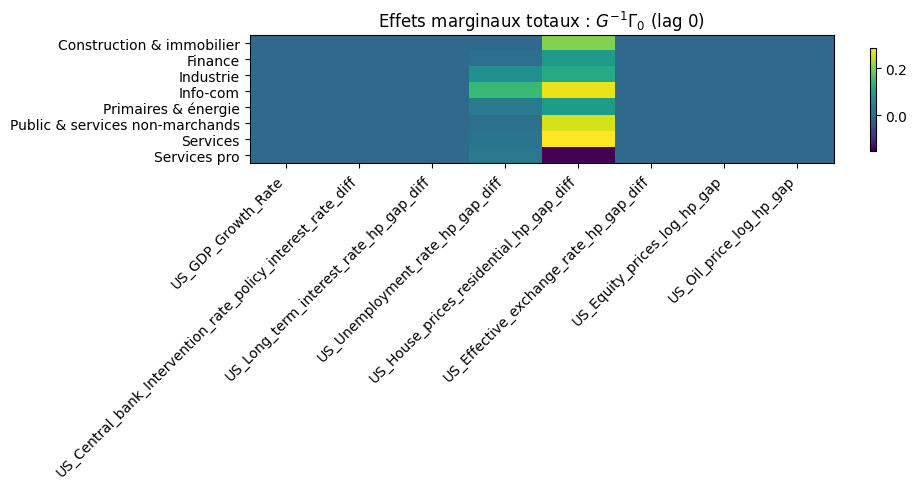

In [41]:
def plot_heatmap(df, title):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(df.values, aspect="auto")
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

# Exemple : effet marginal total à l=0 (impact immédiat)
plot_heatmap(tildeGamma[0], "Effets marginaux totaux : $G^{-1}\\Gamma_0$ (lag 0)")

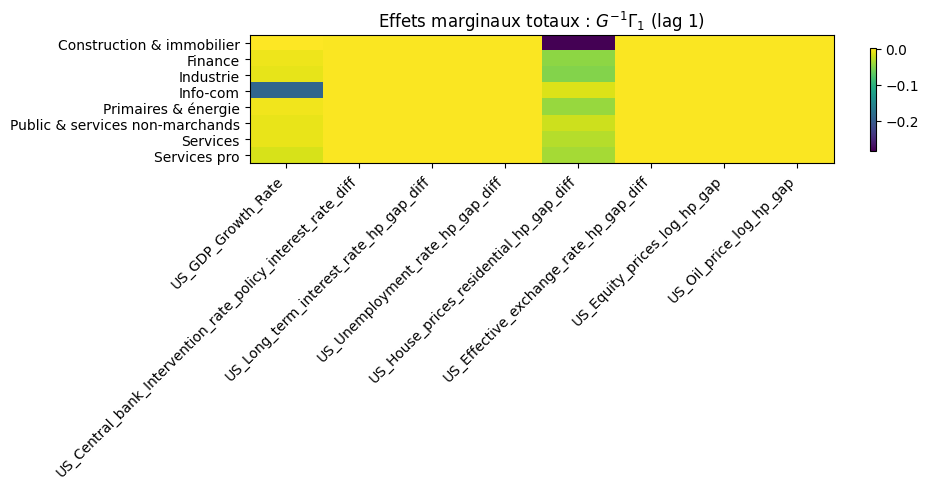

In [84]:
# Exemple : effet marginal total à l=1 (impact à 1 an)
plot_heatmap(tildeGamma[1], "Effets marginaux totaux : $G^{-1}\\Gamma_1$ (lag 1)")

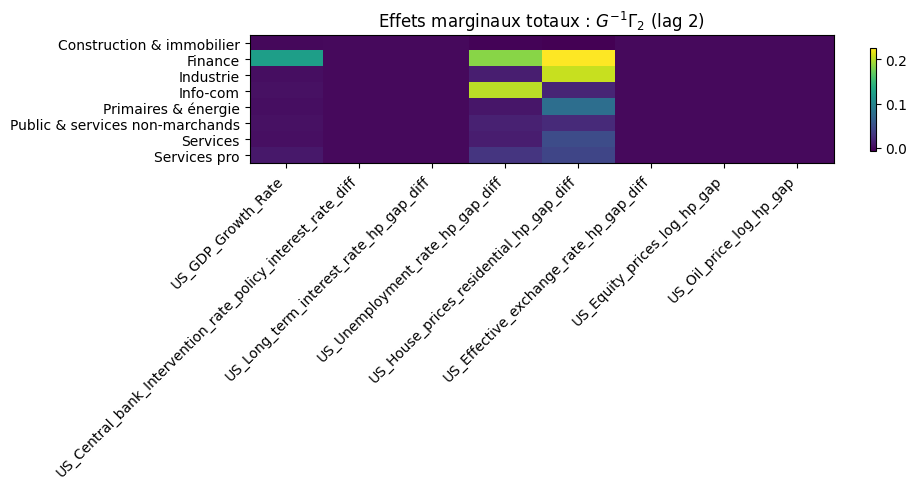

In [85]:
# Exemple : effet marginal total à l=2 (impact à 2 ans)
plot_heatmap(tildeGamma[2], "Effets marginaux totaux : $G^{-1}\\Gamma_2$ (lag 2)")

In [ ]:
def spatial_decomposition(B0: np.ndarray, Gamma_l: np.ndarray, k_max=10, tol=1e-10):
    """
    Renvoie la liste [B0^0 Gamma_l, B0^1 Gamma_l, ..., B0^k Gamma_l]
    où chaque terme est (N,K).
    """
    N, K = Gamma_l.shape
    out = []
    Bk = np.eye(N)
    for k in range(k_max + 1):
        term = Bk @ Gamma_l
        out.append(term)
        if k > 0 and np.max(np.abs(term)) < tol:
            break
        Bk = Bk @ B0
    return out

B0 = B[0].values
Gamma0 = Gamma[0].values  # ou Gamma[l].values

terms_l0 = spatial_decomposition(B0, Gamma0, k_max=12)  # liste de (N,K)

In [96]:
terms_l1 = spatial_decomposition(B0, Gamma[1].values, k_max=12)
terms_l2 = spatial_decomposition(B0, Gamma[2].values, k_max=12)
terms_l3 = spatial_decomposition(B0, Gamma[3].values, k_max=12)
terms_l4 = spatial_decomposition(B0, Gamma[4].values, k_max=12) 

In [91]:
import matplotlib.pyplot as plt
def plot_spatial_for_one(sector, macro, terms, sectors, macros, cumulative=True):
    i = sectors.index(sector)
    j = macros.index(macro)
    vals = np.array([t[i, j] for t in terms])
    if cumulative:
        vals = np.cumsum(vals)
        ylabel = "Effet marginal cumulé"
    else:
        ylabel = "Contribution par voisinage k"
    plt.figure(figsize=(9,4))
    plt.plot(range(len(vals)), vals)
    plt.title(f"Décomposition spatiale (macro={macro}) sur {sector}")
    plt.xlabel("Ordre de voisinage k")
    plt.ylabel(ylabel)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

sectors = list(W.index)
macros = list(Gamma[0].columns)

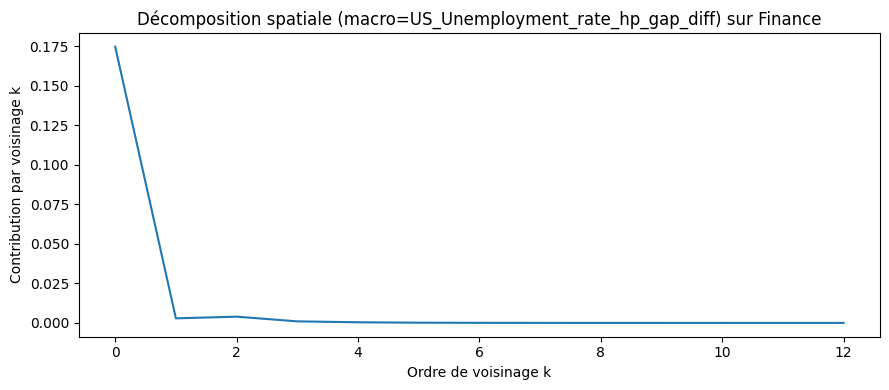

In [97]:
plot_spatial_for_one("Finance", macros[3], terms_l2, sectors, macros, cumulative=False)

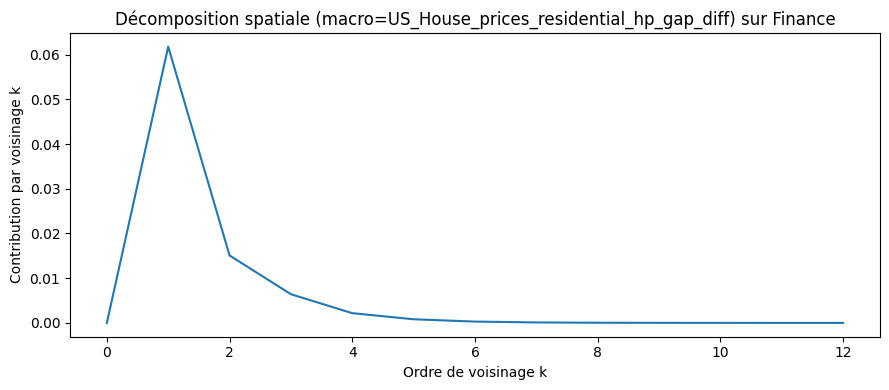

In [93]:
plot_spatial_for_one("Finance", macros[4], terms_l0, sectors, macros, cumulative=False)

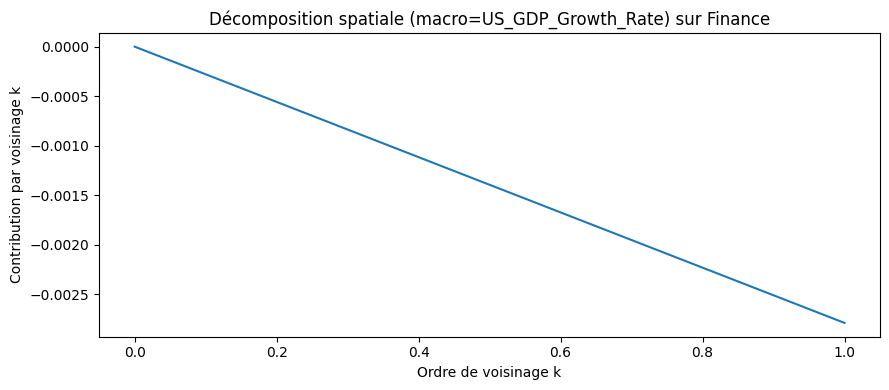

In [89]:
plot_spatial_for_one("Finance", macros[0], terms_l1, sectors, macros, cumulative=False)

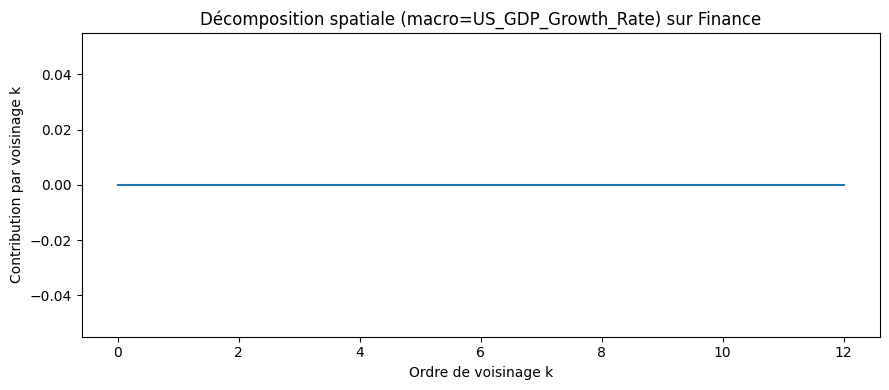

In [90]:
plot_spatial_for_one("Finance", macros[0], terms_l3, sectors, macros, cumulative=False)

######################################################################################################################

In [48]:
# Z doit déjà contenir les secteurs (même ordre que W.index)
Z_hist = Z[sectors].dropna().copy()

In [49]:
Z_hist

sector,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439
2011-10-01,-1.656445,-1.228758,-0.130107,-0.198410,0.949014,0.643175,-0.834454,-2.045196
2012-01-01,1.672773,-0.611153,-0.170126,-0.358526,0.778933,0.083938,-0.810922,-1.409588
2012-04-01,-1.552605,0.600996,-0.041919,0.890062,-0.154775,-0.131946,0.371942,-0.410847
2012-07-01,-1.456050,0.900720,-0.216857,-0.450470,-0.166745,1.693689,0.398834,-0.410847


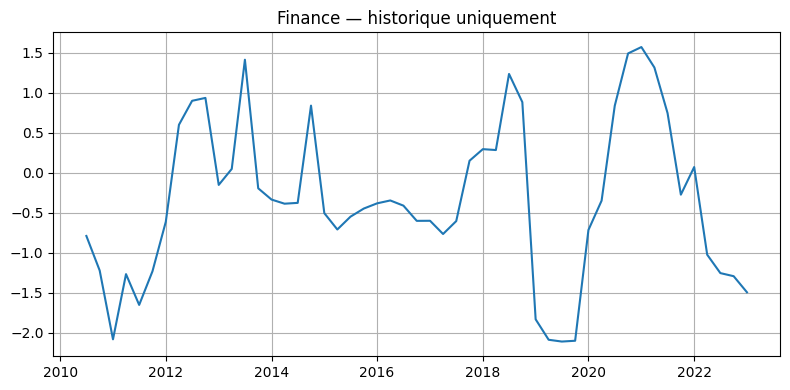

In [50]:
import matplotlib.pyplot as plt
sector = "Finance"
plt.figure(figsize=(8,4))
plt.plot(Z_hist.index, Z_hist[sector])
plt.title("Finance — historique uniquement")
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
Z_init = Z_hist.iloc[-P_star:].copy()

In [52]:
Z_init

sector,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
year_quarter,,,,,,,,
2022-04-01,-0.278737,-1.021741,-1.538531,-0.801970,-1.330749,-1.679586,-1.062600,0.755457
2022-07-01,-1.162396,-1.251673,-1.430418,-1.240405,-0.579247,-1.452828,-0.972914,0.711422
2022-10-01,1.634512,-1.290416,-1.266050,-2.127625,-0.930985,-1.456367,-1.625503,-0.904612
2023-01-01,1.609668,-1.491594,-1.988983,-2.187928,-0.579247,-2.003627,-1.354102,1.059470


In [53]:
print(Z_init.shape)        # doit être (P_star, N)
print(Z_init.columns)      # doit être exactement W.index
print(Z_init.index)        # dernières dates historiques

(4, 8)
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str', name='sector')
DatetimeIndex(['2022-04-01', '2022-07-01', '2022-10-01', '2023-01-01'], dtype='datetime64[us]', name='year_quarter', freq=None)


In [54]:
# X_scenario : index = dates, colonnes = macros (K)
X_scenario = X_scenario
X_scenario.index = pd.to_datetime(X_scenario.index)

last_hist_date = pd.to_datetime(Z_hist.index[-1])

# Garder uniquement les dates futures
X_scenario_future = X_scenario[X_scenario.index >= last_hist_date].copy()

print("Last hist:", last_hist_date)
print("Scenario start:", X_scenario_future.index[0] if len(X_scenario_future)>0 else None)
print("Scenario shape:", X_scenario_future.shape)

Last hist: 2023-01-01 00:00:00
Scenario start: None
Scenario shape: (0, 10)


In [55]:
print("---- CHECK DIMENSIONS ----")
print("P_star =", P_star)
print("L =", L)

print("Z_init shape:", Z_init.shape)
print("Z_init columns:", Z_init.columns)

print("F keys:", F.keys())
print("F[1] shape:", F[1].shape if P_star >= 1 else None)

print("tildeGamma keys:", tildeGamma.keys())
print("tildeGamma[0] shape:", tildeGamma[0].shape)

print("X_future shape:", X_scenario_future.shape)
print("X_future columns:", X_scenario_future.columns)

print("Nb sectors:", len(Z_init.columns))
print("Nb macros:", len(X_scenario_future.columns))

---- CHECK DIMENSIONS ----
P_star = 4
L = 4
Z_init shape: (4, 8)
Z_init columns: Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str', name='sector')
F keys: dict_keys([1, 2, 3, 4])
F[1] shape: (8, 8)
tildeGamma keys: dict_keys([0, 1, 2, 3, 4])
tildeGamma[0] shape: (8, 8)
X_future shape: (0, 10)
X_future columns: Index(['date', 'US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='str')
Nb sectors: 8
Nb macros: 10


In [56]:
X_scenario_future.columns

Index(['date', 'US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='str')

In [57]:
macro_cols

['US_GDP_Growth_Rate',
 'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
 'US_Long_term_interest_rate_hp_gap_diff',
 'US_Unemployment_rate_hp_gap_diff',
 'US_House_prices_residential_hp_gap_diff',
 'US_Effective_exchange_rate_hp_gap_diff',
 'US_Equity_prices_log_hp_gap',
 'US_Oil_price_log_hp_gap']

In [58]:
from statsmodels.tsa.filters.hp_filter import hpfilter
import numpy as np
import pandas as pd

def hp_gap(series, lamb=1600):
    s = series.astype(float)
    cycle, trend = hpfilter(s.dropna(), lamb=lamb)
    return cycle.reindex(series.index)

def safe_log(series):
    s = series.astype(float)
    return np.log(s.where(s > 0))

def transform_macro_dataset(df_raw):
    """
    Applique exactement les mêmes transformations que pour l'estimation.
    Retourne un DataFrame transformé.
    """

    df = df_raw.copy()

    # --- HP gaps ---
    df["US_Unemployment_rate_hp_gap"] = hp_gap(df["US_Unemployment_rate"])
    df["US_Unemployment_rate_hp_gap_diff"] = df["US_Unemployment_rate_hp_gap"].diff()

    df["US_Long_term_interest_rate_hp_gap"] = hp_gap(df["US_Long_term_interest_rate"])
    df["US_Long_term_interest_rate_hp_gap_diff"] = \
        df["US_Long_term_interest_rate_hp_gap"].diff()

    df["US_House_prices_residential_hp_gap"] = hp_gap(df["US_House_prices_residential"])
    df["US_House_prices_residential_hp_gap_diff"] = df["US_House_prices_residential_hp_gap"].diff()

    df["US_Effective_exchange_rate_hp_gap"] = hp_gap(df["US_Effective_exchange_rate"])
    df["US_Effective_exchange_rate_hp_gap_diff"] = df["US_Effective_exchange_rate_hp_gap"].diff()

    # --- Diff directe ---
    df["US_Central_bank_Intervention_rate_policy_interest_rate_diff"] = \
        df["US_Central_bank_Intervention_rate_policy_interest_rate"].diff()

    # --- Logs + HP ---
    df["US_Equity_prices_log"] = safe_log(df["US_Equity_prices"])
    df["US_Equity_prices_log_hp_gap"] = hp_gap(df["US_Equity_prices_log"])

    df["US_Oil_price_log"] = safe_log(df["US_Oil_price"])
    df["US_Oil_price_log_hp_gap"] = hp_gap(df["US_Oil_price_log"])

    df["US_GDP_log"] = safe_log(df["US_GDP_Growth_Rate"])
    df["US_GDP_log_hp_gap"] = hp_gap(df["US_GDP_log"])
    df["US_GDP_log_hp_gap_diff"] = df["US_GDP_log_hp_gap"].diff()

    return df

In [59]:
X_hist = pd.read_csv("data/macro_data/df_macro_stationary1.csv")

In [60]:
X_full = pd.concat([X_hist, X_scenario_future])
X_full_transformed = transform_macro_dataset(X_full)

# ensuite séparer
X_scenario_transformed = X_full_transformed.loc[X_scenario_future.index]

In [61]:
macro_cols = list(tildeGamma[0].columns)

In [62]:
X_scenario_final = X_scenario_transformed[macro_cols].copy()

In [63]:
import pandas as pd
import numpy as np

def project_gvar(Z_init, X_scenario, mu, F, tildeGamma, P_star, L):
    """
    Z_init: DataFrame (P_star x N) dernières valeurs observées, colonnes=secteurs
    X_scenario: DataFrame (H x K) index=dates, colonnes=macro_cols (sans 'date' en colonne)
    mu: array (N,1)
    F: dict p-> DataFrame (N x N), p=1..P_star
    tildeGamma: dict l-> DataFrame (N x K), l=0..L
    """
    sectors = list(Z_init.columns)
    N = len(sectors)
    H = len(X_scenario)

    # On garde un historique avec les bonnes colonnes
    Z_lags = Z_init.copy()

    projections = []

    for h in range(H):
        z_new = mu.copy()

        # dynamique sectorielle
        for p in range(1, P_star + 1):
            z_lag = Z_lags.iloc[-p][sectors].values.reshape(N, 1)
            z_new += F[p].values @ z_lag

        # bloc macro
        for l in range(0, L + 1):
            if h - l >= 0:
                x_val = X_scenario.iloc[h - l].values.reshape(-1, 1)
                z_new += tildeGamma[l].values @ x_val

        # stocker projection
        projections.append(z_new.ravel())

        # AJOUTER UNE LIGNE avec les MÊMES colonnes
        new_row = pd.DataFrame([z_new.ravel()], columns=sectors, index=[X_scenario.index[h]])
        Z_lags = pd.concat([Z_lags, new_row], axis=0)

    Z_proj = pd.DataFrame(projections, index=X_scenario.index, columns=sectors)
    return Z_proj

In [64]:
Z_proj_baseline = project_gvar(
    Z_init,
    X_scenario_final,
    mu,
    F,
    tildeGamma,
    P_star,
    L
)

print("Z_proj_baseline:", Z_proj_baseline.shape)
Z_proj_baseline.head()

Z_proj_baseline: (0, 8)


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro


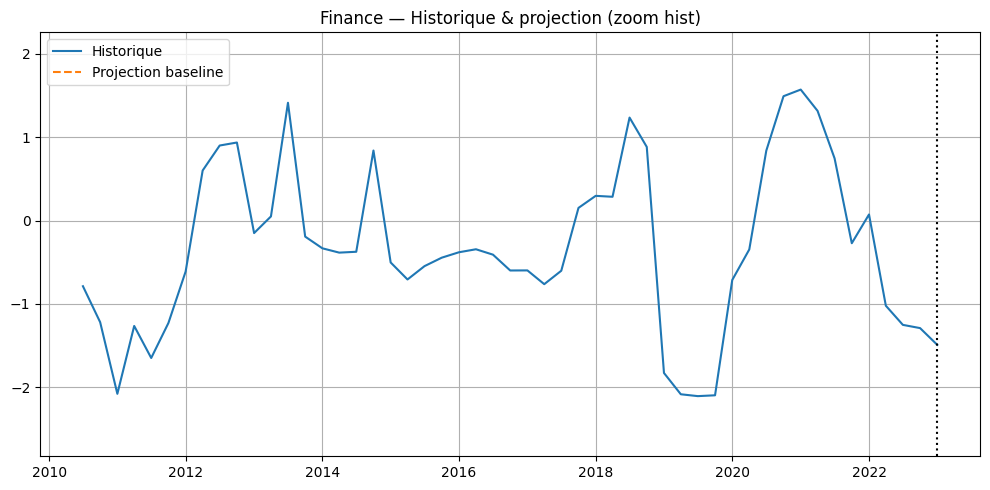

In [65]:
import matplotlib.pyplot as plt
import numpy as np

sector ="Finance"

y_hist = Z_hist[sector].values
ymin, ymax = np.nanpercentile(y_hist, [1, 99])   # robustes aux outliers
pad = 0.2 * (ymax - ymin)

plt.figure(figsize=(10,5))
plt.plot(Z_hist.index, Z_hist[sector], label="Historique")
plt.plot(Z_proj_baseline.index, Z_proj_baseline[sector], "--", label="Projection baseline")
plt.axvline(Z_hist.index[-1], color="black", linestyle=":")

plt.ylim(ymin - pad, ymax + pad)  # 👈 fixe l’échelle selon l’historique
plt.title(f"{sector} — Historique & projection (zoom hist)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
import numpy as np

N = len(sectors)
P = P_star

# Companion matrix
top = np.hstack([F[p].values for p in range(1, P+1)])        # (N, N*P)
bottom = np.eye(N*(P-1), N*P)                                # (N*(P-1), N*P)
companion = np.vstack([top, bottom])                         # (N*P, N*P)

eigvals = np.linalg.eigvals(companion)
print("Max |eig| =", np.max(np.abs(eigvals)))

Max |eig| = 0.6986354871187568


L’estimation OLS initiale produisait une dynamique instable (rayon spectral > 1), entraînant des projections explosives à long horizon.
Nous avons donc utilisé une estimation Ridge afin de régulariser les coefficients et garantir la stabilité dynamique du système (max |λ| < 1).
Cette approche est standard dans les modèles macro-financiers à forte dimension

IndexError: index 0 is out of bounds for axis 0 with size 0

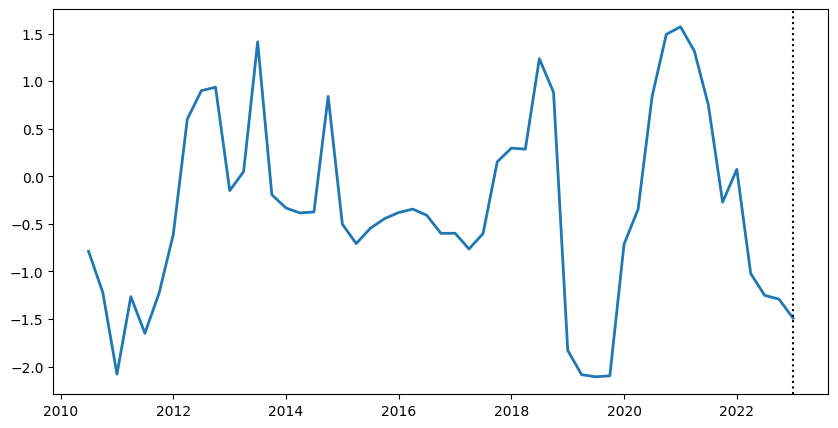

In [ ]:
sector = "Finance"

# Historique
hist_dates = Z_hist.index
hist_values = Z_hist[sector]

# Projection
proj_dates = Z_proj_baseline.index
proj_values = Z_proj_baseline[sector]

plt.figure(figsize=(10,5))

# Historique
plt.plot(hist_dates, hist_values, 
         color="#1f77b4", linewidth=2, label="Historique")

# Projection (ligne pleine, plus fine)
plt.plot(proj_dates, proj_values, 
         color="#d62728", linewidth=2, label="Projection baseline")

# Ligne verticale séparation
plt.axvline(hist_dates[-1], color="black", linestyle=":", linewidth=1.5)

# Zone projection grisée
plt.axvspan(hist_dates[-1], proj_dates[-1], 
            color="grey", alpha=0.08)

plt.title(f"{sector} — Historique et projection baseline", fontsize=13)
plt.ylabel("Facteur sectoriel")
plt.xlabel("Date")

plt.legend(frameon=False)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

IndexError: index -1 is out of bounds for axis 0 with size 0

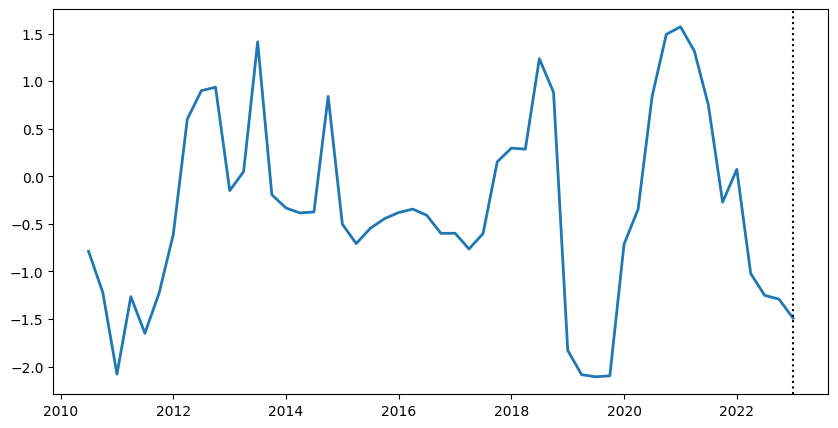

In [70]:
# concaténer pour une ligne continue
combined = pd.concat([hist_values, proj_values])

plt.figure(figsize=(10,5))
plt.plot(combined.index, combined.values,
         color="#1f77b4", linewidth=2)

plt.axvline(hist_dates[-1], color="black", linestyle=":", linewidth=1.5)
plt.axvspan(hist_dates[-1], proj_dates[-1], color="grey", alpha=0.08)

plt.title(f"{sector} — Dynamique projetée", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.style.use("seaborn-v0_8-whitegrid")

Et les autres scénarios 

In [71]:
X_Zero = pd.read_csv("data/ngfs_data/X_Net_Zero_2050.csv")

In [72]:
X_Zero = X_Zero.set_index("date")

In [73]:
X_Zero.columns

Index(['US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='str')

In [74]:
X_Zero.index = pd.to_datetime(X_Zero.index)

In [75]:
# Garder uniquement les dates futures
X_Zero_future = X_Zero[X_Zero.index >= last_hist_date].copy()

In [76]:
X_full_zero = pd.concat([X_hist, X_Zero_future])
X_full_transformed_zero = transform_macro_dataset(X_full_zero)

# ensuite séparer
X_zero_transformed = X_full_transformed_zero.loc[X_Zero_future.index]

In [77]:
import pandas as pd

def project_one_scenario(
    scenario_csv_path,
    scenario_name,
    X_hist_raw,
    macro_cols,
    transform_func,
    last_hist_date,
    Z_init,
    mu,
    F,
    tildeGamma,
    P_star,
    L
):
    """
    Charge un scénario, applique transformations cohérentes,
    projette le GVAR et retourne la projection sectorielle.
    """

    # 1️⃣ Charger scénario brut
    X_scen = pd.read_csv(scenario_csv_path)
    X_scen = X_scen.set_index("date")
    X_scen.index = pd.to_datetime(X_scen.index)

    # 2️⃣ Garder uniquement futur
    X_future_raw = X_scen[X_scen.index >= last_hist_date].copy()

    # 3️⃣ Concat historique + futur (important pour HP filter)
    X_full = pd.concat([X_hist_raw, X_future_raw])

    # 4️⃣ Appliquer mêmes transformations
    X_full_transformed = transform_func(X_full)

    # 5️⃣ Extraire partie future transformée
    X_future_transformed = X_full_transformed.loc[X_future_raw.index]

    # 6️⃣ Garder uniquement colonnes du modèle
    X_future_final = X_future_transformed[macro_cols].copy()

    # 7️⃣ Projection GVAR
    Z_proj = project_gvar(
        Z_init,
        X_future_final,
        mu,
        F,
        tildeGamma,
        P_star,
        L
    )

    print(f"✔ Projection terminée : {scenario_name}")

    return Z_proj

In [78]:
scenario_files = {
    "Baseline": "data/ngfs_data/X_Baseline.csv",
    "Below 2°C": "data/ngfs_data/X_Below_2C.csv",
    "Current Policies": "data/ngfs_data/X_Current_Policies.csv",
    "Delayed Transition": "data/ngfs_data/X_Delayed_transition.csv",
    "Fragmented World": "data/ngfs_data/X_Fragmented_World.csv",
    "NDC": "data/ngfs_data/X_Nationally_Determined_Contribut.csv",
    "Net Zero 2050": "data/ngfs_data/X_Net_Zero_2050.csv"
}

Z_projections = {}

for scen_name, scen_path in scenario_files.items():
    Z_projections[scen_name] = project_one_scenario(
        scenario_csv_path=scen_path,
        scenario_name=scen_name,
        X_hist_raw=X_hist,                     # macro historique brute
        macro_cols=macro_cols,
        transform_func=transform_macro_dataset,
        last_hist_date=last_hist_date,
        Z_init=Z_init,
        mu=mu,
        F=F,
        tildeGamma=tildeGamma,
        P_star=P_star,
        L=L
    )

✔ Projection terminée : Baseline
✔ Projection terminée : Below 2°C
✔ Projection terminée : Current Policies
✔ Projection terminée : Delayed Transition
✔ Projection terminée : Fragmented World
✔ Projection terminée : NDC
✔ Projection terminée : Net Zero 2050


In [79]:
import matplotlib.pyplot as plt

def plot_sector_scenarios(sector, Z_hist, Z_projections):

    plt.figure(figsize=(11,6))

    # Historique
    plt.plot(Z_hist.index, Z_hist[sector],
             color="black", linewidth=2.5, label="Historique")

    # Projections
    for scen_name, Z_proj in Z_projections.items():
        plt.plot(Z_proj.index, Z_proj[sector],
                 linewidth=2, label=scen_name)

    # Séparation
    plt.axvline(Z_hist.index[-1], color="black", linestyle=":", linewidth=1.5)

    plt.title(f"{sector} — Comparaison des scénarios NGFS", fontsize=14)
    plt.ylabel("Facteur sectoriel")
    plt.xlabel("Date")
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

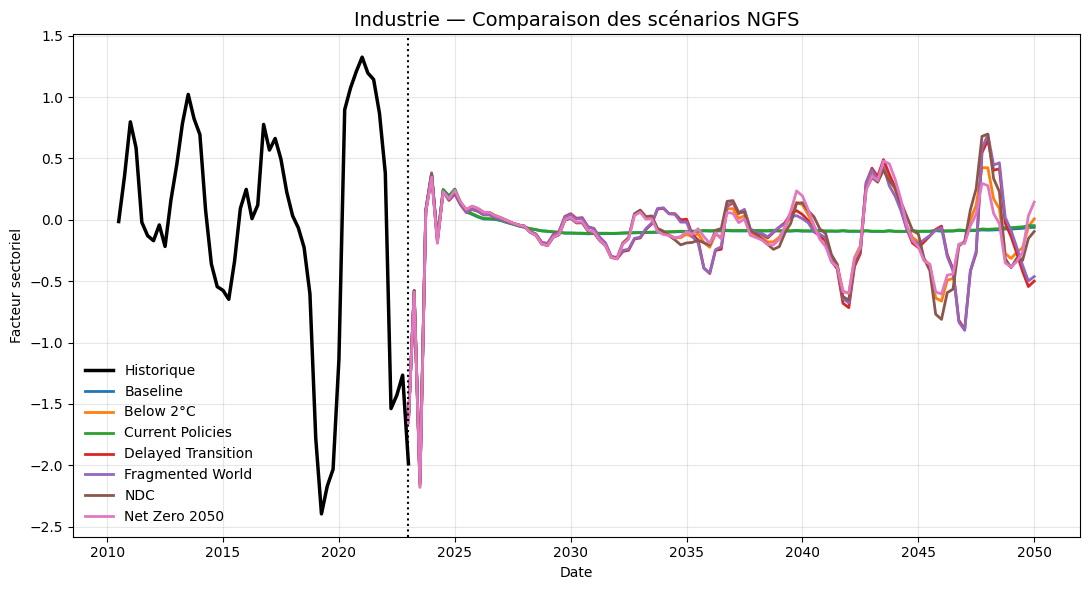

In [80]:
plot_sector_scenarios(
    sector="Industrie",
    Z_hist=Z_hist,
    Z_projections=Z_projections
)

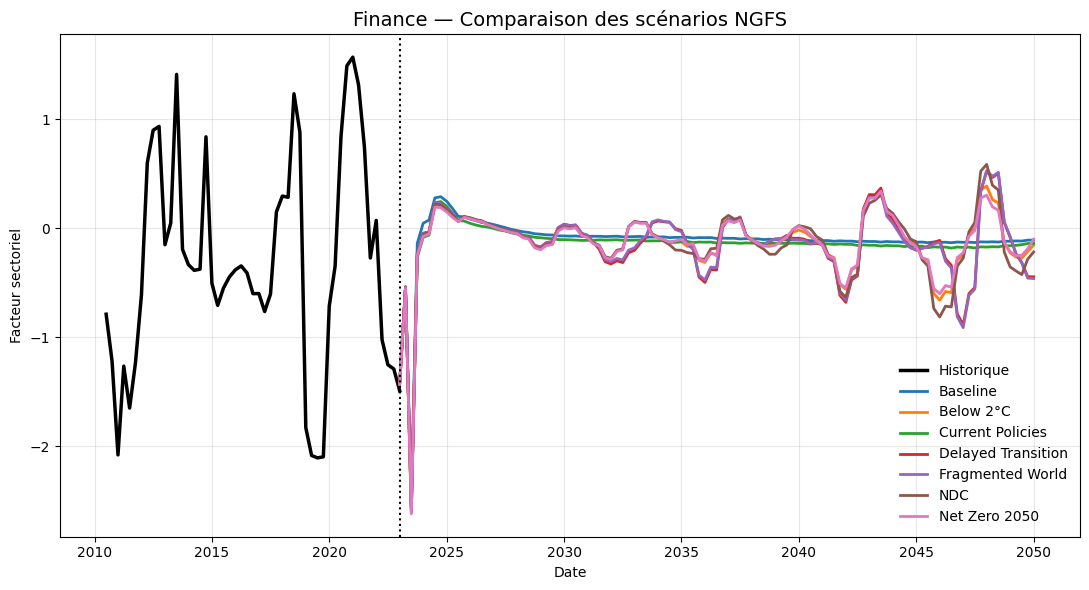

In [81]:
plot_sector_scenarios(
    sector="Finance",
    Z_hist=Z_hist,
    Z_projections=Z_projections
)

In [ ]:
plot_sector_scenarios(
    sector="Extractions primaire",
    Z_hist=Z_hist,
    Z_projections=Z_projections
)

KeyError: 'Extraction primaire'

<Figure size 1100x600 with 0 Axes>

################# fin 3 

In [ ]:
Z_tilde = Z_hist - Z_hist.mean()
X_tilde = X - X.mean()

Z_tilde.head()

sector,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
year_quarter,,,,,,,,
2010-07-01,-3.138333,-0.453741,0.037194,-3.049030,2.498536,-1.242202,-1.745810,-1.710290
2010-10-01,-1.679502,-0.885338,0.406513,-0.441343,0.599902,-0.455153,-0.907661,-1.037630
2011-01-01,1.409756,-1.745052,0.849871,-0.192206,0.715458,-0.582979,-0.901225,-1.456711
2011-04-01,1.781791,-0.930586,0.638351,-0.011573,1.248828,0.452384,-1.228601,-1.456711
2011-07-01,1.911032,-1.315111,0.030786,-0.002485,0.994675,0.450939,-0.476116,-1.456711


In [ ]:

N = len(sectors)
P = P_star

top = np.hstack([F[p].values for p in range(1, P+1)])
bottom = np.eye(N*(P-1), N*P)

companion = np.vstack([top, bottom])

eigvals = np.linalg.eigvals(companion)

print("Max |eig| =", np.max(np.abs(eigvals)))

Max |eig| = 0.6986354871187566


In [ ]:
def compute_phi_matrices(F, H=10):
    
    Phi = {}
    N = F[1].shape[0]
    
    Phi[0] = np.eye(N)
    
    for h in range(1, H+1):
        Phi[h] = np.zeros((N, N))
        for p in range(1, min(P_star, h) + 1):
            Phi[h] += Phi[h-p] @ F[p].values
            
    return Phi

H = 10  # horizon GIRF
Phi = compute_phi_matrices(F, H=H)

In [ ]:
def build_regression_dataset(df_all, sector, Pmax=4, Lmax=4):
    
    df = pd.DataFrame(index=df_all.index)

    # variable dépendante
    df["y"] = df_all[sector]

    # Zstar lags
    for p in range(Pmax+1):
        df[f"ZstarL{p}"] = df_all[f"{sector}_star"].shift(p)

    # macro lags
    for col in macro_cols:
        for l in range(Lmax+1):
            df[f"X_L{l}_{col}"] = df_all[col].shift(l)

    df["const"] = 1.0

    return df.dropna()

In [ ]:
from sklearn.linear_model import Ridge

def build_residuals_df_ridge(df_all, sectors, coef_df, Pmax=4, Lmax=4, alpha=10.0):

    residuals = {}

    for s in sectors:

        df_reg = build_regression_dataset(df_all, s, Pmax, Lmax)

        kept_cols = coef_df.loc[s].dropna().index.tolist()

        if "const" not in kept_cols:
            kept_cols = ["const"] + kept_cols

        y = df_reg["y"].values
        X = df_reg[kept_cols].values

        model = Ridge(alpha=alpha, fit_intercept=False)
        model.fit(X, y)

        yhat = model.predict(X)
        resid = y - yhat

        residuals[s] = pd.Series(resid, index=df_reg.index)

    residuals_df = pd.DataFrame(residuals).dropna()
    residuals_df = residuals_df[sectors]

    return residuals_df

In [ ]:
residuals_df = build_residuals_df_ridge(
    df_all,
    sectors,
    coef_df,
    Pmax=4,
    Lmax=4,
    alpha=10.0
)

print(residuals_df.shape)
residuals_df.head()

(47, 8)


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
2011-07-01,1.766649,-1.055245,-0.057365,0.100843,0.306007,0.123978,-0.716367,-1.235691
2011-10-01,-1.423774,-0.608107,0.177790,0.050784,0.522856,0.698637,-0.347118,-0.547811
2012-01-01,2.129616,-0.292601,-0.078670,-0.150729,0.618344,0.195981,-0.315422,-0.313942
2012-04-01,-1.542353,0.921097,0.159083,0.704670,0.143146,-0.157949,0.384420,0.133830
2012-07-01,-1.270913,1.193379,-0.071290,-0.577251,-0.077877,1.617016,0.301315,0.035163


In [ ]:
residuals = residuals_df.values   # dataframe des résidus empilés

Sigma_eps = np.cov(residuals.T)

Sigma_eps

array([[ 0.7504363 , -0.10506558, -0.01843499, -0.0256074 ,  0.07617921,
        -0.16444984, -0.08627163, -0.10006045],
       [-0.10506558,  0.39182001,  0.0232164 ,  0.08452355, -0.06507659,
         0.06181394,  0.11595135,  0.10119849],
       [-0.01843499,  0.0232164 ,  0.15914593,  0.06257355,  0.02869864,
         0.03978376,  0.03737998,  0.0219141 ],
       [-0.0256074 ,  0.08452355,  0.06257355,  0.27259531, -0.07807625,
         0.09079399, -0.01162092, -0.11771559],
       [ 0.07617921, -0.06507659,  0.02869864, -0.07807625,  0.39737849,
        -0.14373883,  0.11537488,  0.19664086],
       [-0.16444984,  0.06181394,  0.03978376,  0.09079399, -0.14373883,
         0.51543495, -0.02517511, -0.1139155 ],
       [-0.08627163,  0.11595135,  0.03737998, -0.01162092,  0.11537488,
        -0.02517511,  0.15960348,  0.16332419],
       [-0.10006045,  0.10119849,  0.0219141 , -0.11771559,  0.19664086,
        -0.1139155 ,  0.16332419,  0.84999526]])

In [ ]:

Sigma_eta = Ginv @ Sigma_eps @ Ginv.T

Sigma_eta

array([[ 0.76613917, -0.0519686 ,  0.04268439, -0.04165035,  0.12485725,
        -0.1613474 , -0.06502065, -0.09161039],
       [-0.0519686 ,  0.47759917,  0.12230465,  0.15315582,  0.04154516,
         0.16006296,  0.20199288,  0.26973175],
       [ 0.04268439,  0.12230465,  0.26726847,  0.12300429,  0.19462831,
         0.14915282,  0.1545516 ,  0.16998754],
       [-0.04165035,  0.15315582,  0.12300429,  0.30414543, -0.00273315,
         0.15717742,  0.06352287,  0.01903355],
       [ 0.12485725,  0.04154516,  0.19462831, -0.00273315,  0.52891058,
        -0.02727984,  0.22085259,  0.31580366],
       [-0.1613474 ,  0.16006296,  0.14915282,  0.15717742, -0.02727984,
         0.53371855,  0.08190846,  0.04572998],
       [-0.06502065,  0.20199288,  0.1545516 ,  0.06352287,  0.22085259,
         0.08190846,  0.24168616,  0.29438581],
       [-0.09161039,  0.26973175,  0.16998754,  0.01903355,  0.31580366,
         0.04572998,  0.29438581,  0.97539684]])

In [ ]:


def compute_girf(Phi, Sigma_eta, shock_index, H=10):
    
    N = Sigma_eta.shape[0]
    e_j = np.zeros(N)
    e_j[shock_index] = 1
    
    sigma_jj = Sigma_eta[shock_index, shock_index]
    
    girf = []
    
    for h in range(H+1):
        response = Phi[h] @ Sigma_eta @ e_j / np.sqrt(sigma_jj)
        girf.append(response)
        
    return np.array(girf)

# Exemple : choc sur Industrie lourde
shock_sector = "Industrie"
shock_index = sectors.index(shock_sector)

girf_industrie = compute_girf(Phi, Sigma_eta, shock_index, H=10)

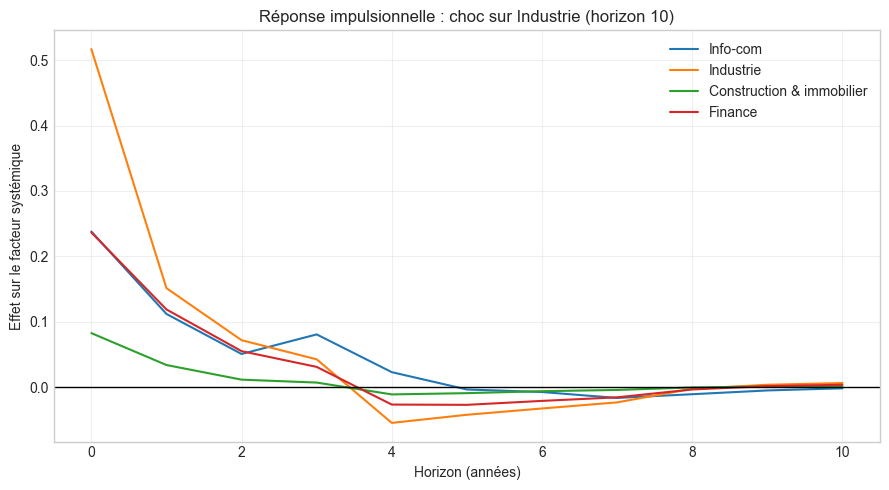

In [ ]:


affected_sectors = ["Info-com", "Industrie", 
                    "Construction & immobilier", 
                    "Finance"]

plt.figure(figsize=(9,5))

for s in affected_sectors:
    idx = sectors.index(s)
    plt.plot(range(H+1), girf_industrie[:, idx], label=s)

plt.axhline(0, color="black", linewidth=1)
plt.title("Réponse impulsionnelle : choc sur Industrie (horizon 10)")
plt.xlabel("Horizon (années)")
plt.ylabel("Effet sur le facteur systémique")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
shock_sector = "Finance"
shock_index = sectors.index(shock_sector)

girf_construction = compute_girf(Phi, Sigma_eta, shock_index, H=10)

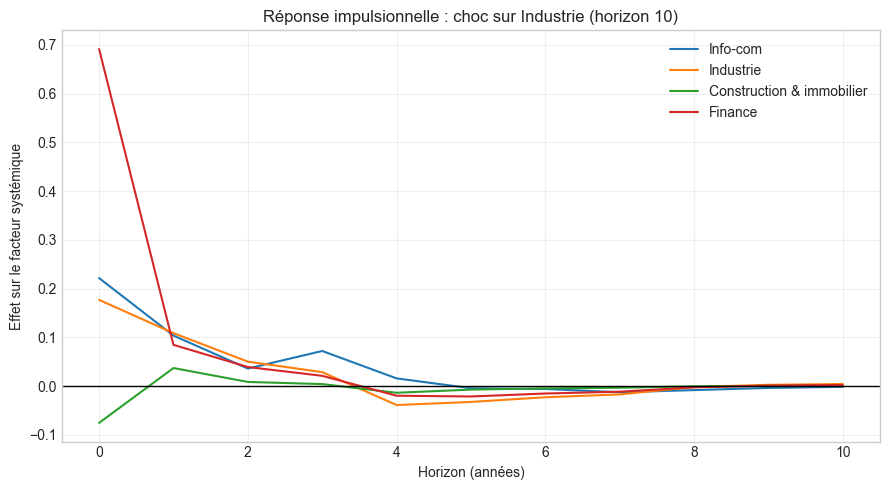

In [ ]:
affected_sectors = ["Info-com", "Industrie", 
                    "Construction & immobilier", 
                    "Finance"]

plt.figure(figsize=(9,5))

for s in affected_sectors:
    idx = sectors.index(s)
    plt.plot(range(H+1), girf_construction[:, idx], label=s)

plt.axhline(0, color="black", linewidth=1)
plt.title("Réponse impulsionnelle : choc sur Industrie (horizon 10)")
plt.xlabel("Horizon (années)")
plt.ylabel("Effet sur le facteur systémique")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import os

output_dir = "data/output/Z_projections"
os.makedirs(output_dir, exist_ok=True)

for scen_name, Z_df in Z_projections.items():
    
    # Nettoyer nom pour fichier
    scen_file = scen_name.replace(" ", "_").replace("°", "")
    
    file_path = os.path.join(output_dir, f"Z_{scen_file}.csv")
    
    Z_df_export = Z_df.copy()
    Z_df_export.index.name = "date"
    
    Z_df_export.to_csv(file_path)
    
    print(f"✔ Exporté : {file_path}")

✔ Exporté : data/output/Z_projections\Z_Baseline.csv
✔ Exporté : data/output/Z_projections\Z_Below_2C.csv
✔ Exporté : data/output/Z_projections\Z_Current_Policies.csv
✔ Exporté : data/output/Z_projections\Z_Delayed_Transition.csv
✔ Exporté : data/output/Z_projections\Z_Fragmented_World.csv
✔ Exporté : data/output/Z_projections\Z_NDC.csv
✔ Exporté : data/output/Z_projections\Z_Net_Zero_2050.csv


##################################################

Cette partie présente les essaies pour ajuster le modèle ( ne la prend pas en compte)

In [ ]:
def build_design_sector(df_all, sector, P_star, L, macro_cols):
    
    # Variable dépendante
    y = df_all[sector]
    
    X_parts = []
    
    # Z_star lags
    for p in range(0, P_star + 1):
        X_parts.append(df_all[f"{sector}_star"].shift(p).rename(f"ZstarL{p}"))
    
    # Macros lags
    for l in range(0, L + 1):
        X_parts.append(
            df_all[macro_cols].shift(l).add_prefix(f"X_L{l}_")
        )
    
    Xreg = pd.concat(X_parts, axis=1)
    Xreg = sm.add_constant(Xreg, has_constant="add")
    
    df_reg = pd.concat([y.rename("y"), Xreg], axis=1).dropna()
    
    return df_reg

In [ ]:
X.columns

Index(['US_GDP_Growth_Rate',
       'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'US_Long_term_interest_rate_hp_gap_diff',
       'US_Unemployment_rate_hp_gap_diff',
       'US_House_prices_residential_hp_gap_diff',
       'US_Effective_exchange_rate_hp_gap_diff', 'US_Equity_prices_log_hp_gap',
       'US_Oil_price_log_hp_gap'],
      dtype='object')

In [ ]:
macro_cols = list(X.columns)

sector = "Finance"

df_reg = build_design_sector(
    df_all=df_all,
    sector=sector,
    P_star=1,
    L=0,
    macro_cols=macro_cols
)

df_reg.head()

,y,const,ZstarL0,ZstarL1,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,X_L0_US_House_prices_residential_hp_gap_diff,X_L0_US_Effective_exchange_rate_hp_gap_diff,X_L0_US_Equity_prices_log_hp_gap,X_L0_US_Oil_price_log_hp_gap
2010-10-01,-1.219453,1.0,-1.024763,-1.865200,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-2.079168,1.0,-0.290600,-1.024763,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,-1.264702,1.0,0.040945,-0.290600,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,-1.649227,1.0,0.162462,0.040945,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724
2011-10-01,-1.228758,1.0,-0.665851,0.162462,1.123049,0.0,-0.313187,-0.149268,-0.344489,2.121182,-0.067994,0.092499


In [ ]:
res = sm.OLS(df_reg["y"], df_reg.drop(columns="y")).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     7.079
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           3.22e-06
Time:                        18:32:30   Log-Likelihood:                -44.679
No. Observations:                  50   AIC:                             111.4
Df Residuals:                      39   BIC:                             132.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [ ]:
def select_lags_sector(df_all, sector, macro_cols,
                       P_grid=(0,1,2,3),
                       L_grid=(0,1,2,3)):
    
    results = []
    
    for P_star in P_grid:
        for L in L_grid:
            
            try:
                df_reg = build_design_sector(df_all, sector, P_star, L, macro_cols)
                res = sm.OLS(df_reg["y"], df_reg.drop(columns="y")).fit()
                
                results.append({
                    "P_star": P_star,
                    "L": L,
                    "BIC": res.bic
                })
            except:
                continue
    
    return pd.DataFrame(results).sort_values("BIC")

In [ ]:
select_lags_sector(
    df_all,
    sector="Finance",
    macro_cols=macro_cols
)

,P_star,L,BIC
4,1,0,132.390288
8,2,0,134.316682
12,3,0,135.008991
0,0,0,136.965401
1,0,1,156.893464
5,1,1,160.781912
9,2,1,161.202123
13,3,1,162.273932
2,0,2,169.716843
6,1,2,173.046140


##################################################

In [ ]:
def lag_series(s: pd.Series, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag d'une série."""
    out = []
    for l in range(0, max_lag + 1):
        out.append(s.shift(l).rename(f"{prefix}L{l}"))
    return pd.concat(out, axis=1)

def lag_dataframe(df: pd.DataFrame, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag de toutes les colonnes d'un DF."""
    out = []
    for l in range(0, max_lag + 1):
        tmp = df.shift(l).add_prefix(f"{prefix}L{l}_")
        out.append(tmp)
    return pd.concat(out, axis=1)


#Estimation OLS secteur par secteur 

In [ ]:
def estimate_sector_varx(
    df_all: pd.DataFrame,
    sector: str,
    macro_cols: list[str],
    P: int,
    P_star: int,
    L: int
):
    """
    Estime: Z_i(t) ~ const + lags(Z_i, 1..P) + lags(Z_i*, 0..P_star) + lags(X, 0..L)
    """
    y = df_all[sector]

    # --- Retards domestiques (1..P)
    X_dom = []
    for p in range(1, P + 1):
        X_dom.append(df_all[sector].shift(p).rename(f"ZL{p}"))

    X_dom = pd.concat(X_dom, axis=1) if X_dom else None

    # --- Retards étrangers (0..P_star)
    star_col = f"{sector}_star"
    X_star = lag_series(df_all[star_col], P_star, prefix="Zstar")  # L0..LP_star

    # --- Retards macro (0..L)
    X_macro = lag_dataframe(df_all[macro_cols], L, prefix="X_") if macro_cols else None

    # --- Assemblage régressions
    X_parts = []
    if X_dom is not None:
        X_parts.append(X_dom)
    X_parts.append(X_star)
    if X_macro is not None:
        X_parts.append(X_macro)

    Xreg = pd.concat(X_parts, axis=1)
    data = pd.concat([y.rename("y"), Xreg], axis=1).dropna()

    y2 = data["y"]
    X2 = sm.add_constant(data.drop(columns=["y"]))
    model = sm.OLS(y2, X2).fit()

    return model

macro_cols = list(X.columns)

models = {}
residuals = {}
coefs = {}

for s in W.index:
    m = estimate_sector_varx(df_all, sector=s, macro_cols=macro_cols, P=P, P_star=P_star, L=L)
    models[s] = m
    residuals[s] = m.resid
    coefs[s] = m.params

# Exemple d'output
first_sector = W.index[0]
print(first_sector)
print(models[first_sector].summary())


Construction & immobilier
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     1.080
Date:                Fri, 20 Feb 2026   Prob (F-statistic):              0.417
Time:                        14:45:32   Log-Likelihood:                -56.581
No. Observations:                  50   AIC:                             155.2
Df Residuals:                      29   BIC:                             195.3
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [ ]:
coef_df = pd.DataFrame(coefs).T  # index=secteurs, colonnes=params
coef_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))

resid_df = pd.DataFrame(residuals).dropna()
resid_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

print("Saved:")
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

coef_df.head()


Saved:
 - data/output\gvar_step1_coef_all.csv
 - data/output\gvar_step1_residuals.csv


,const,ZstarL0,ZstarL1,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate,X_L0_US_Effective_exchange_rate,X_L0_US_Equity_prices,X_L0_US_GDP_Growth_Rate,X_L0_US_House_prices_residential,X_L0_US_Inflation_rate,X_L0_US_Long_term_interest_rate,...,X_L0_US_Unemployment_rate,X_L1_US_Central_bank_Intervention_rate_policy_interest_rate,X_L1_US_Effective_exchange_rate,X_L1_US_Equity_prices,X_L1_US_GDP_Growth_Rate,X_L1_US_House_prices_residential,X_L1_US_Inflation_rate,X_L1_US_Long_term_interest_rate,X_L1_US_Oil_price,X_L1_US_Unemployment_rate
Construction & immobilier,-1.634401,-0.418786,0.466567,-0.863210,-0.040446,0.023194,0.012176,-0.013994,0.512673,0.499599,...,0.194652,0.657733,0.099963,0.020229,0.052261,-0.092695,-0.026669,0.656588,0.013466,0.170478
Finance,11.614532,0.648238,0.169937,2.196593,0.005354,0.004929,-0.076189,-0.024582,-0.169540,0.427655,...,0.216194,-1.650595,-0.052180,0.059256,-0.020005,-0.092943,-0.021109,-1.145893,0.012330,-0.030366
Industrie,-3.251662,0.866543,0.324345,-1.090398,-0.002508,0.008406,-0.057178,-0.198258,-0.046634,0.672695,...,-0.032380,0.563748,0.030221,-0.009143,-0.004230,0.206848,0.036634,-0.314100,0.003676,0.111300
Info-com,5.070416,-0.009650,0.591865,0.986693,-0.047682,-0.004179,0.362046,-0.190479,-0.043376,0.157729,...,0.751001,-0.968540,0.048659,0.060933,0.073143,0.084791,-0.105863,-0.404091,0.027866,-0.416413
Primaires & énergie,9.969597,0.810540,0.562820,0.210929,-0.018003,-0.013714,0.192660,-0.379683,0.509337,-0.627363,...,0.283745,0.676223,-0.035984,0.004010,0.162814,0.367582,0.023386,-0.343602,-0.021228,-0.107841


# Construction du GVAR 

In [ ]:
def build_B_matrices(W: pd.DataFrame, coef_df: pd.DataFrame, P_star: int):
    """
    Construit B_p pour p=0..P_star à partir des coefficients beta_i,p = coef['ZstarLp'].
    """
    N = W.shape[0]
    sectors = list(W.index)

    # sécurité : diagonale W nulle
    W2 = W.copy()
    np.fill_diagonal(W2.values, 0.0)

    B = {}
    for p in range(0, P_star + 1):
        # vecteur beta_{i,p} pour tous i
        beta_name = f"ZstarL{p}"
        if beta_name not in coef_df.columns:
            raise ValueError(f"Colonne manquante dans coef_df: {beta_name}")

        beta_vec = coef_df.loc[sectors, beta_name].values.reshape(-1, 1)  # (N,1)

        # B_p = diag(beta_vec) * W
        Bp = (beta_vec * W2.values)  # broadcasting ligne i
        np.fill_diagonal(Bp, 0.0)    # imposer (i,i)=0
        B[p] = pd.DataFrame(Bp, index=sectors, columns=sectors)

    return B

B = build_B_matrices(W, coef_df, P_star=P_star)

# Vérifier dimensions
print("B0 shape:", B[0].shape)

# Matrice G = I - B0 (utile si tu as un contemporain)
I = np.eye(W.shape[0])
G = pd.DataFrame(I - B[0].values, index=W.index, columns=W.columns)

# Vérifier inversibilité numérique (conditionnement)
cond_G = np.linalg.cond(G.values)
det_G = np.linalg.det(G.values)

print("det(G) =", det_G)
print("cond(G) =", cond_G)


B0 shape: (8, 8)
det(G) = 0.7390816524701281
cond(G) = 4.0648011653389915


In [ ]:
def build_Gamma_matrices(coef_df, sectors, macro_cols, L):

    Gamma = {}

    for l in range(0, L+1):

        # noms exacts des colonnes pour ce lag
        cols_l = [f"X_L{l}_{mc}" for mc in macro_cols]

        # vérifier qu'elles existent
        for c in cols_l:
            if c not in coef_df.columns:
                raise ValueError(f"Colonne manquante : {c}")

        Gl = coef_df.loc[sectors, cols_l].values  # matrice m x K

        Gamma[l] = pd.DataFrame(
            Gl,
            index=sectors,
            columns=macro_cols
        )

    return Gamma

In [ ]:
coef_df.columns

Index(['const', 'ZstarL0', 'ZstarL1',
       'X_L0_US_Central_bank_Intervention_rate_policy_interest_rate',
       'X_L0_US_Effective_exchange_rate', 'X_L0_US_Equity_prices',
       'X_L0_US_GDP_Growth_Rate', 'X_L0_US_House_prices_residential',
       'X_L0_US_Inflation_rate', 'X_L0_US_Long_term_interest_rate',
       'X_L0_US_Oil_price', 'X_L0_US_Unemployment_rate',
       'X_L1_US_Central_bank_Intervention_rate_policy_interest_rate',
       'X_L1_US_Effective_exchange_rate', 'X_L1_US_Equity_prices',
       'X_L1_US_GDP_Growth_Rate', 'X_L1_US_House_prices_residential',
       'X_L1_US_Inflation_rate', 'X_L1_US_Long_term_interest_rate',
       'X_L1_US_Oil_price', 'X_L1_US_Unemployment_rate'],
      dtype='object')

In [ ]:
macro_cols = [
    'US_Central_bank_Intervention_rate_policy_interest_rate',
    'US_Effective_exchange_rate',
    'US_Equity_prices',
    'US_GDP_Growth_Rate',
    'US_House_prices_residential',
    'US_Inflation_rate',
    'US_Long_term_interest_rate',
    'US_Oil_price',
    'US_Unemployment_rate'
]

In [ ]:
sectors = list(W.index)

In [ ]:
Gamma = build_Gamma_matrices(
    coef_df=coef_df,
    sectors=sectors,
    macro_cols=macro_cols,
    L=1
)

In [ ]:
Gamma

{0:                                  US_Central_bank_Intervention_rate_policy_interest_rate  \
 Construction & immobilier                                                -0.863210        
 Finance                                                                   2.196593        
 Industrie                                                                -1.090398        
 Info-com                                                                  0.986693        
 Primaires & énergie                                                       0.210929        
 Public & services non-marchands                                           1.761028        
 Services                                                                  1.062897        
 Services pro                                                             -0.516194        
 
                                  US_Effective_exchange_rate  US_Equity_prices  \
 Construction & immobilier                         -0.040446          0.023194   
 Fi

In [ ]:
G_inv = np.linalg.inv(G_mat.values)

####################

In [ ]:
P1 = 4
L=4

In [ ]:
F = {}

for p in range(1, P1+1):
    F[p] = pd.DataFrame(
        G_inv @ B[p].values,
        index=sectors,
        columns=sectors
    )

In [ ]:
tildeGamma = {}

for l in range(0, L+1):
    tildeGamma[l] = pd.DataFrame(
        G_inv @ Gamma[l].values,
        index=sectors,
        columns=macro_cols
    )

In [ ]:
alpha = coef_df.loc[sectors, "const"].values.reshape(-1,1)

mu = G_inv @ alpha

In [ ]:
eigvals = np.linalg.eigvals(F[1].values)
print(np.abs(eigvals).max())

0.7414510962678487


un modele stable donc ! 

## PRojections 

In [ ]:
import pandas as pd
import numpy as np

def project_gvar(Z_init, X_scenario, mu, F, tildeGamma, P_star, L):
    """
    Z_init: DataFrame (P_star x N) dernières valeurs observées, colonnes=secteurs
    X_scenario: DataFrame (H x K) index=dates, colonnes=macro_cols (sans 'date' en colonne)
    mu: array (N,1)
    F: dict p-> DataFrame (N x N), p=1..P_star
    tildeGamma: dict l-> DataFrame (N x K), l=0..L
    """
    sectors = list(Z_init.columns)
    N = len(sectors)
    H = len(X_scenario)

    # On garde un historique avec les bonnes colonnes
    Z_lags = Z_init.copy()

    projections = []

    for h in range(H):
        z_new = mu.copy()

        # dynamique sectorielle
        for p in range(1, P_star + 1):
            z_lag = Z_lags.iloc[-p][sectors].values.reshape(N, 1)
            z_new += F[p].values @ z_lag

        # bloc macro
        for l in range(0, L + 1):
            if h - l >= 0:
                x_val = X_scenario.iloc[h - l].values.reshape(-1, 1)
                z_new += tildeGamma[l].values @ x_val

        # stocker projection
        projections.append(z_new.ravel())

        # AJOUTER UNE LIGNE avec les MÊMES colonnes
        new_row = pd.DataFrame([z_new.ravel()], columns=sectors, index=[X_scenario.index[h]])
        Z_lags = pd.concat([Z_lags, new_row], axis=0)

    Z_proj = pd.DataFrame(projections, index=X_scenario.index, columns=sectors)
    return Z_proj

In [ ]:
Z_hist = Z[sectors].dropna()

Z_init = Z_hist.iloc[-P_star:].copy()

In [ ]:
Z_init

sector,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
year_quarter,,,,,,,,
2023-01-01,1.609668,-1.491594,-1.988983,-2.187928,-0.579247,-2.003627,-1.354102,1.05947


In [ ]:
print("Nombre secteurs dans W :", len(W.index))
print("Shape F[1] :", F[1].shape)
print("Colonnes Z_init :", len(Z_init.columns))
print("Z_init columns :", Z_init.columns)

Nombre secteurs dans W : 8
Shape F[1] : (8, 8)
Colonnes Z_init : 8
Z_init columns : Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object', name='sector')


In [ ]:
X_scenario=pd.read_csv("data/ngfs_data/ngfs_us.csv")

In [ ]:
X_scenario = X_scenario.set_index("date")

In [ ]:
X_scenario.index = pd.to_datetime(X_scenario.index)

In [ ]:
last_hist_date = Z_hist.index[-1]

X_scenario = X_scenario[X_scenario.index > last_hist_date]

In [ ]:
Z_proj = project_gvar(
    Z_init=Z_init,
    X_scenario=X_scenario,
    mu=mu,
    F=F,
    tildeGamma=tildeGamma,
    P_star=P_star,
    L=L
)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 9 is different from 8)

In [ ]:
print(X_scenario.columns)

Index(['US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='object')


In [ ]:
Z_hist = Z_hist.copy()
Z_proj = Z_proj.copy()

Z_hist.index = pd.to_datetime(Z_hist.index)
Z_proj.index = pd.to_datetime(Z_proj.index)

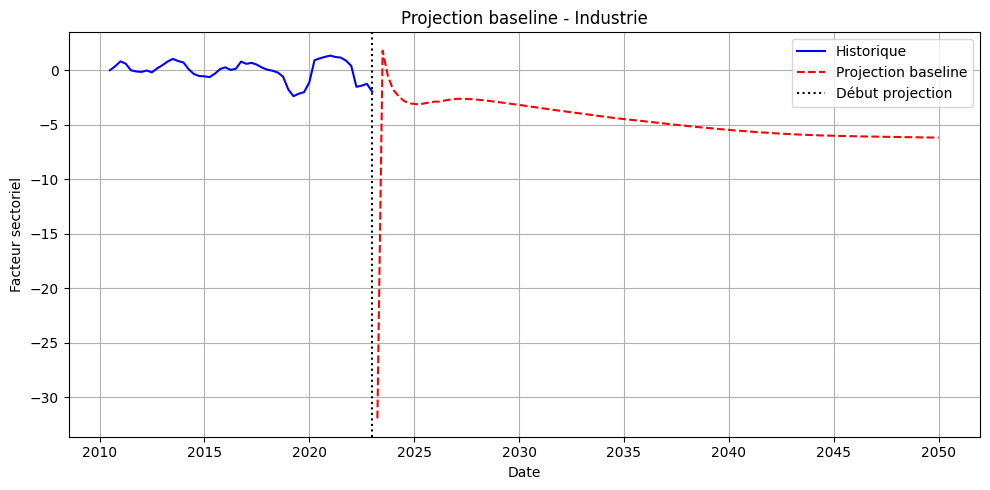

In [ ]:
import matplotlib.pyplot as plt

sector_to_plot = "Industrie"  # adapte si besoin

# concat historique + projection
Z_full = pd.concat([Z_hist[sector_to_plot], Z_proj[sector_to_plot]])

plt.figure(figsize=(10,5))

# Historique
plt.plot(Z_hist.index,
         Z_hist[sector_to_plot],
         label="Historique",
         color="blue")

# Projection
plt.plot(Z_proj.index,
         Z_proj[sector_to_plot],
         label="Projection baseline",
         linestyle="--",
         color="red")

plt.axvline(Z_hist.index[-1], color="black", linestyle=":", label="Début projection")

plt.title(f"Projection baseline - {sector_to_plot}")
plt.xlabel("Date")
plt.ylabel("Facteur sectoriel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(Z_hist.index[-1])
print(X_scenario.index[0])

2023-01-01 00:00:00
2022-01-01
